# [Trajectory Analysis] Figure 5

## The amount of information available to the mouse correlates inversely with infotaxis behavior. 

For reference, here is the full figure

![dual_occlusion](final_figures/multi_occlusion.jpg) 

and corresponding supplemental figure

![Supplemental dual_occlusion](final_figures/supp_multi_occlusion.jpg)

In [2]:
cd "/app/"

/app


/app/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

/app/.venv/lib/python3.9/site-packages/datajoint/plugin.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-26 08:34:43,867][INFO]: Connecting admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
[2026-02-26 08:34:44,076][INFO]: Connected admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from vr4mice.analysis.analysis import style
from vr4mice.schema import vr4mice
from vr4mice.analysis import utils, plotting, analysis
from vr4mice.schema.vr4mice import Groups, Labels
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanXYTrajectory, MeanVelocities
from vr4mice.analysis.stats import get_multi_p_values_binned, get_multi_p_values_global, plot_aperture_heatmap
from statsmodels.stats.anova import AnovaRM
import statsmodels.formula.api as smf
import scipy.stats as stats

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

/app/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
trial_df = (Groups() * (Labels()  & 'label = "ar_paper"') * (vr4mice.Dataset() & 'session_label = "ar_discrim_5_occluders"') * TrialMetrics()).fetch(as_dict=True)
trial_df = pd.concat([pd.DataFrame(x) for x in trial_df])
trial_df ["aperture"] = trial_df.aperture.round(2)
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df[["dataset", "aperture", "trial", "trial_left_choice", "trial_rewarded", "trial_tortuosity", "trial_duration"]],
                                                        return_excluded=False)

# Create list of included datasets
sessions_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

In [6]:
trial_df.mouse_name.nunique(), trial_df.dataset.nunique()

(9, 25)

In [7]:
trial_df.groupby("mouse_name").nunique().dataset

mouse_name
31726          2
31728          2
J729           4
Jacana         2
Kiwi           3
Lemming        3
Nightingale    4
Oribi          3
Pheasant       2
Name: dataset, dtype: int64

In [8]:
trial_df.dataset.unique()

array(['31726_2025-03-27_1', '31726_2025-03-28_1', '31728_2025-03-11_1',
       '31728_2025-03-14_1', 'J729_2024-12-11_1', 'J729_2024-12-12_1',
       'J729_2024-12-13_1', 'J729_2024-12-15_1', 'Jacana_2024-08-21_1',
       'Jacana_2024-08-22_1', 'Kiwi_2024-08-19_1', 'Kiwi_2024-08-20_1',
       'Kiwi_2024-08-21_1', 'Lemming_2024-08-14_1',
       'Lemming_2024-08-15_1', 'Lemming_2024-08-19_1',
       'Nightingale_2024-08-15_1', 'Nightingale_2024-08-16_1',
       'Nightingale_2024-08-21_1', 'Nightingale_2024-08-22_1',
       'Oribi_2024-08-26_1', 'Oribi_2024-08-27_1', 'Oribi_2024-08-29_1',
       'Pheasant_2024-08-26_1', 'Pheasant_2024-08-28_1'], dtype=object)

In [9]:
trial_df["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

In [10]:
# Linear Mixed Model (with Mouse)
lmm_model = smf.mixedlm("trial_rewarded ~ C(aperture)", 
                        data=trial_df, groups=trial_df["mouse_name"]).fit(method='bfgs')

# Ordinary Least Squares (without Mouse)
ols_model = smf.ols("trial_rewarded ~ C(aperture)", data=trial_df).fit()

# Likelihood Ratio Test
lr_stat = 2 * (lmm_model.llf - ols_model.llf)
p_val = stats.chi2.sf(lr_stat, df=1) # 1 degree of freedom for the random effect

print(f"LRT Statistic: {lr_stat:.4f}")
print(f"P-value for Mouse effect: {p_val:.4f}")

if p_val > 0.05:
    print("Justification: Mouse identity does not significantly improve the model. Independent ANOVA is valid.")
else:
    print("Caution: Mouse identity explains significant variance.")

LRT Statistic: 258.5593
P-value for Mouse effect: 0.0000
Caution: Mouse identity explains significant variance.


                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  0.0901 4.0000 96.0000 0.9854



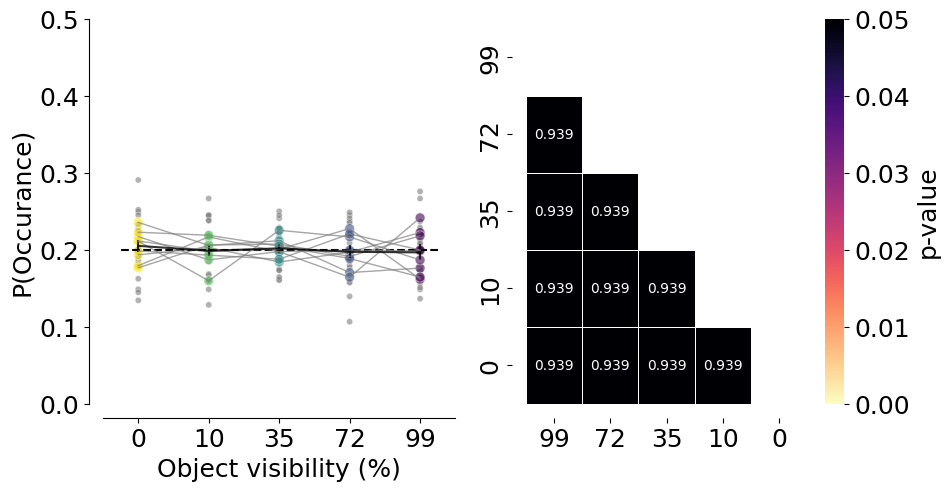

In [11]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts["aperture"] = counts["aperture"].astype("float")
counts = counts.sort_values("aperture")

counts["aperture_numeric"] = counts["aperture"]
aperture_order = counts["aperture"].unique()
counts["aperture"] = pd.Categorical(counts["aperture"].astype("str"), categories=aperture_order.astype("str"), ordered=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
    ax=ax[0]
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    palette=plotting.colors_multi_aperture[::-1],
    alpha=0.6,
    s=50,
    zorder=2,
    ax=ax[0]
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
    ax=ax[0]
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
    ax=ax[0]
)

ax[0].hlines(
    0.2,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax[0].set_ylim(0, .5)
ax[0].set_xlim(-0.5, 4.5)
ax[0].invert_xaxis()

ax[0].set_xticks([4, 3, 2, 1, 0], ["0", "10", "35", "72", "99"])

ax[0].set_xlabel("Object visibility (%)")
ax[0].set_ylabel("P(Occurance)")
sns.despine(offset=10)
ax[0].legend([], [], frameon=False)

# Use numeric aperture for statistical analysis
counts_for_stats = counts.copy()
counts_for_stats['aperture'] = counts_for_stats['aperture_numeric']
p_values = get_multi_p_values_global(counts_for_stats,  y_var="probability")
plot_aperture_heatmap(p_values, ax= ax[1])
ax[1].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[1].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

print(AnovaRM(counts_for_stats, depvar="probability", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure5_occurance.svg", transparent=True)

3.0-4.2: TtestResult(statistic=-2.493988124742931, pvalue=0.019918841916005924, df=24)
3.0-6.0: TtestResult(statistic=-4.3481596890469, pvalue=0.00021792423175303471, df=24)
3.0-8.48: TtestResult(statistic=-5.936285133499774, pvalue=3.986044948258331e-06, df=24)
3.0: mean=0.749 ± 0.021
4.2-6.0: TtestResult(statistic=-2.1904409874229156, pvalue=0.03844327894682323, df=24)
4.2-8.48: TtestResult(statistic=-2.8444593290376323, pvalue=0.008952505101484732, df=24)
4.2: mean=0.819 ± 0.024
6.0-8.48: TtestResult(statistic=-0.4633245496675397, pvalue=0.6473060246641702, df=24)
6.0: mean=0.891 ± 0.021
8.48: mean=0.905 ± 0.017
12.0-3.0: TtestResult(statistic=4.847181901915849, pvalue=6.12561974792148e-05, df=24)
12.0-4.2: TtestResult(statistic=2.6168388007399845, pvalue=0.015117166807783985, df=24)
12.0-6.0: TtestResult(statistic=0.04065996451030943, pvalue=0.9679033410169438, df=24)
12.0-8.48: TtestResult(statistic=-0.5678700816992147, pvalue=0.5753978552200469, df=24)
12.0: mean=0.892 ± 0.019
  

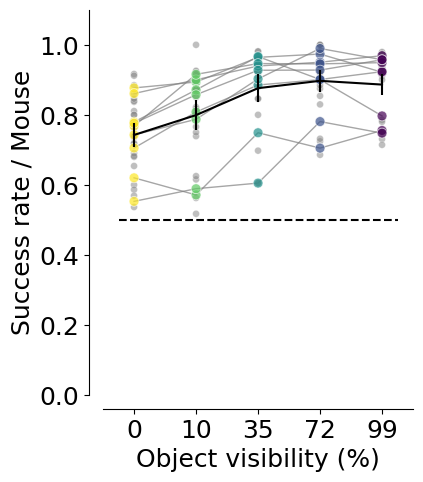

In [12]:
# Success rate per mouse
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax.set_ylim(0, 1.1)
ax.set_xlim(-0.5, 4.5)
ax.set_xlabel("Object visibility (%)")
ax.set_ylabel("Success rate / Mouse")
ax.set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax.legend([], [], frameon=False)
sns.despine(offset=10)

print(AnovaRM(counts_for_stats, depvar="probability", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure5_rewards_per_mouse.svg", transparent=True)

3.0-4.2: TtestResult(statistic=-4.294775142156709, pvalue=0.000249592248485294, df=24)
3.0-6.0: TtestResult(statistic=-8.63596674410741, pvalue=7.938488027221137e-09, df=24)
3.0-8.48: TtestResult(statistic=-9.922891044401927, pvalue=5.716543717984163e-10, df=24)
3.0: mean=0.749 ± 0.021
4.2-6.0: TtestResult(statistic=-4.96095944839423, pvalue=4.5893003535062247e-05, df=24)
4.2-8.48: TtestResult(statistic=-5.653014738081343, pvalue=8.04406204065893e-06, df=24)
4.2: mean=0.819 ± 0.024
6.0-8.48: TtestResult(statistic=-0.9143341342926102, pvalue=0.36963645105671183, df=24)
6.0: mean=0.891 ± 0.021
8.48: mean=0.905 ± 0.017
12.0-3.0: TtestResult(statistic=9.908373156320879, pvalue=5.88184256287188e-10, df=24)
12.0-4.2: TtestResult(statistic=4.653696076204195, pvalue=0.00010017441571757577, df=24)
12.0-6.0: TtestResult(statistic=0.07659887976618203, pvalue=0.9395776368965353, df=24)
12.0-8.48: TtestResult(statistic=-0.931285761959232, pvalue=0.36097991128194373, df=24)
12.0: mean=0.892 ± 0.019


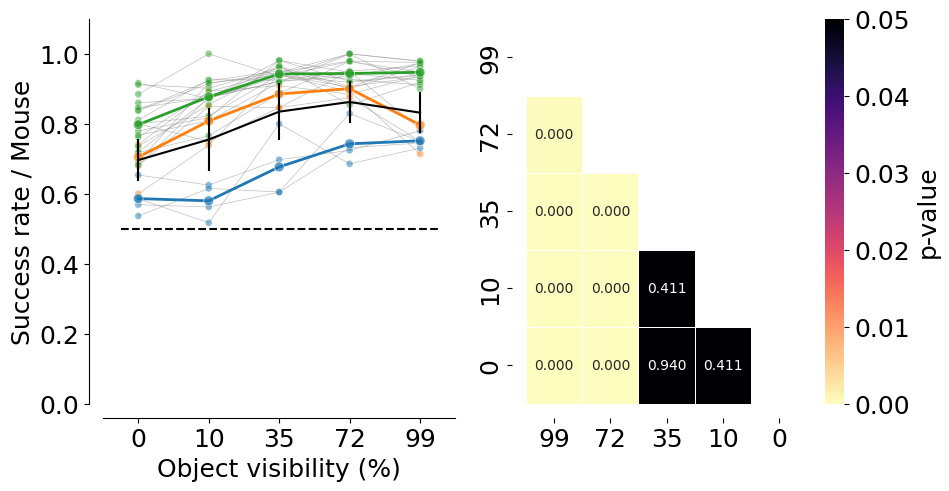

In [13]:
# Success rate per mouse
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[0].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax[0].set_ylim(0, 1.1)
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xlabel("Object visibility (%)")
ax[0].set_ylabel("Success rate / Mouse")
ax[0].set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

p_values = get_multi_p_values_global(trial_df, y_var="trial_rewarded")
plot_aperture_heatmap(p_values, ax=ax[1])
ax[1].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[1].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)
print(AnovaRM(mean_mouse, depvar="trial_rewarded", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure5_rewards.svg", transparent=True)

3.0-4.2: TtestResult(statistic=0.16336372813892353, pvalue=0.8715999221309235, df=24)
3.0-6.0: TtestResult(statistic=0.4605874808001341, pvalue=0.6492408672893397, df=24)
3.0-8.48: TtestResult(statistic=-0.21695206601737546, pvalue=0.8300793967741364, df=24)
3.0: mean=-0.015 ± 0.058
4.2-6.0: TtestResult(statistic=0.24990922807693325, pvalue=0.8047842776180888, df=24)
4.2-8.48: TtestResult(statistic=-0.4639523528123425, pvalue=0.6468625851577114, df=24)
4.2: mean=-0.029 ± 0.050
6.0-8.48: TtestResult(statistic=-0.8071400388375911, pvalue=0.4275128960568405, df=24)
6.0: mean=-0.044 ± 0.029
8.48: mean=-0.002 ± 0.037
12.0-3.0: TtestResult(statistic=1.039734229048693, pvalue=0.30882528560258005, df=24)
12.0-4.2: TtestResult(statistic=1.4772944346317236, pvalue=0.15260002867784161, df=24)
12.0-6.0: TtestResult(statistic=2.278039263657111, pvalue=0.031918811598357646, df=24)
12.0-8.48: TtestResult(statistic=1.0817185531546654, pvalue=0.2901272683683604, df=24)
12.0: mean=0.049 ± 0.034
3.0-4.2:

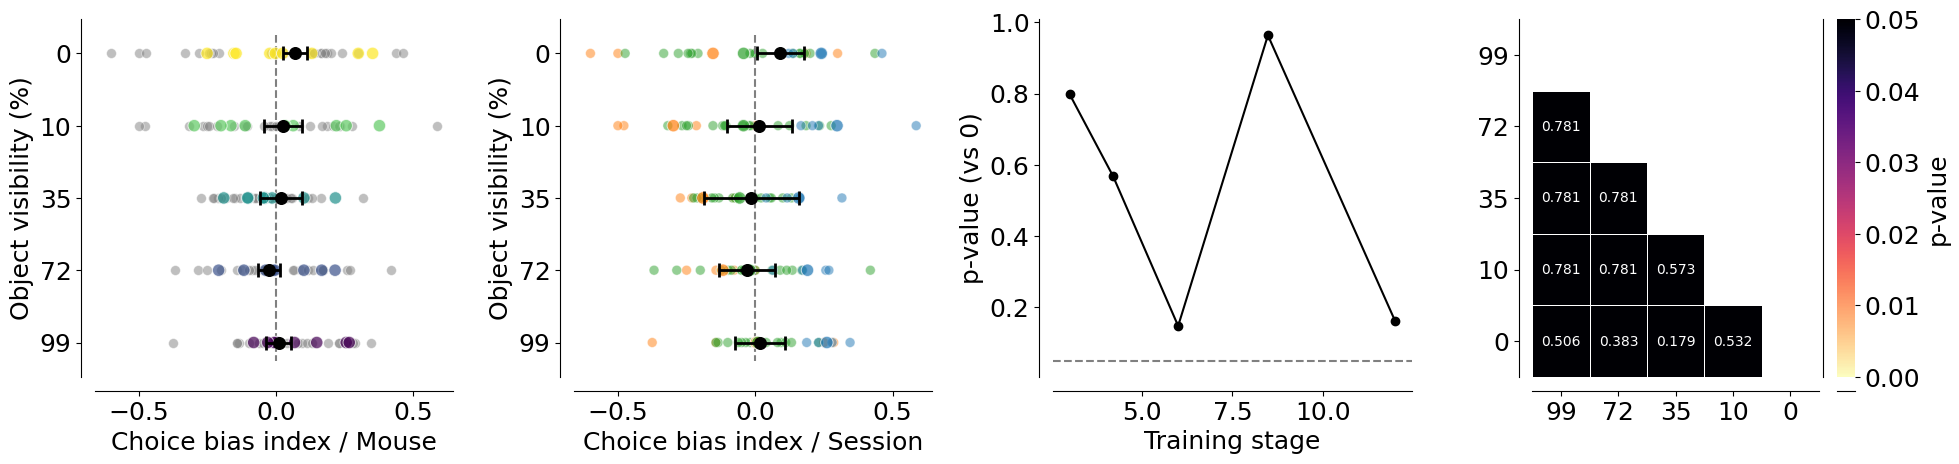

In [33]:
trial_df["trial_bias"] = 2 * trial_df["trial_left_choice"] - 1 

# Choice bias per mouse and per lab
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    plot_bias=True,
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax[0].vlines(
    0,
    ymin=-0.25,
    ymax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="grey",
)

ax[0].set_ylabel("Object visibility (%)")
ax[0].set_xlabel("Choice bias index / Mouse")
ax[0].set_yticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    plot_bias=True,
    ax=ax[1],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[1].vlines(
    0,
    ymin=-0.25,
    ymax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="grey",
)

ax[1].set_ylabel("Object visibility (%)")
ax[1].set_xlabel("Choice bias index / Session")
ax[1].set_yticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[1].legend([], [], frameon=False)

# One-sample t-test of bias against 0 (null) across session
apertures_ = []
for stage in sorted(trial_df.aperture.unique()):
    #vals = trial_df.groupby("dataset").mean().loc[trial_df.aperture == stage, "trial_bias"]
    vals = trial_df[trial_df.aperture == stage].groupby("dataset")["trial_bias"].mean()
    t_stat, p_val = stats.ttest_1samp(vals, 0)
    apertures_.append({
        "aperture": stage,
        "n": len(vals),
        "mean_bias": vals.mean(),
        "t_stat": t_stat,
        "df": max(len(vals) - 1, 0),
        "p_value": p_val,
    })
apertures_df = pd.DataFrame(apertures_)
print("One-sample t-tests vs 0 (bias)")
print(apertures_df)

# Plot p-values only (no bar/box)
ax[2].plot(apertures_df["aperture"], apertures_df["p_value"], 
           marker="o", linestyle="-", color="k")
ax[2].axhline(0.05, color="grey", linestyle="--")
ax[2].set_xlabel("Training stage")
ax[2].set_ylabel("p-value (vs 0)")

# Plot p-values of the multi-comparison test
p_values = get_multi_p_values_global(trial_df, y_var="trial_bias")
plot_aperture_heatmap(p_values, ax=ax[3])
ax[3].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[3].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)
print(AnovaRM(mean_mouse, depvar="trial_bias", subject="dataset", within=["aperture"]).fit())

sns.despine(offset=10)
plt.tight_layout(pad=2)

plt.savefig(save_fig_path + "figure5_choice_bias.svg", transparent=True)

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture 11.8531 4.0000 96.0000 0.0000



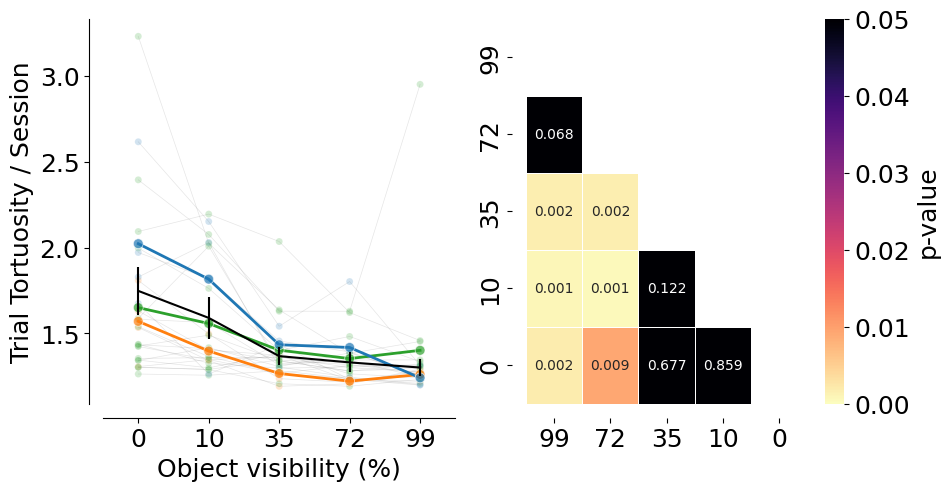

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

counts = (
    trial_df
    .groupby(["lab_id", "dataset", "aperture"], as_index=False)
    .trial_tortuosity.mean()
)

counts["count"] = counts["trial_tortuosity"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_lab=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[0].invert_xaxis()

ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xlabel("Object visibility (%)")
ax[0].set_ylabel("Trial Tortuosity / Session")
ax[0].set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

p_values = get_multi_p_values_global(trial_df,  y_var="trial_tortuosity")
plot_aperture_heatmap(p_values, ax=ax[1])
ax[1].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[1].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)
print(AnovaRM(mean_mouse, depvar="trial_tortuosity", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure5_tortuosity.svg", transparent=True)

## Trajectory analysis

In [16]:
xy_df = []
for m in sessions_list:
    xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
xy_df = pd.concat(xy_df)
xy_df["mouse_name"] = xy_df.dataset.str.split("_").str [0]

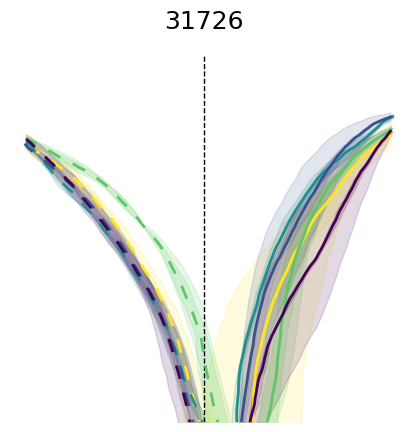

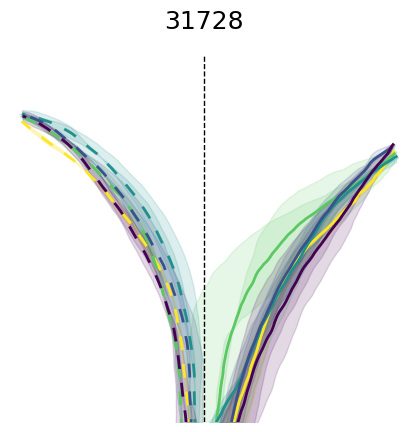

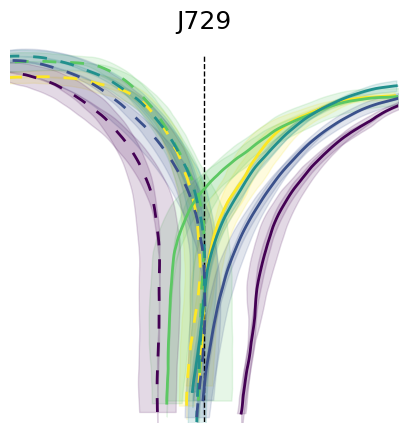

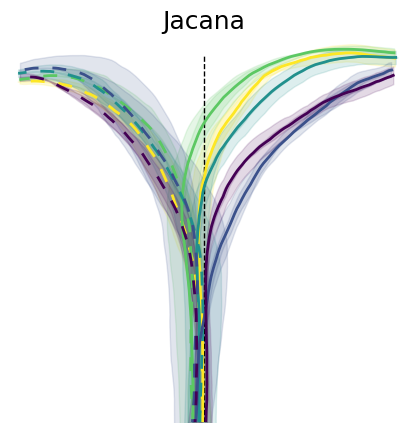

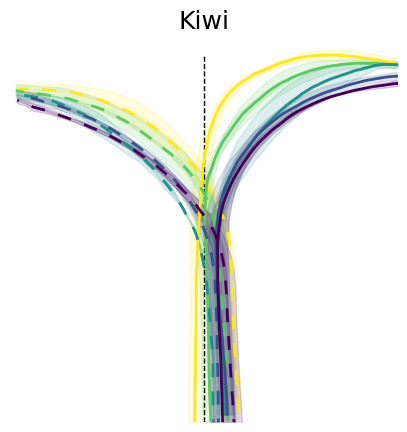

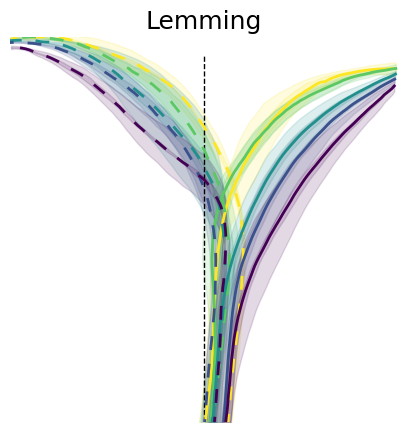

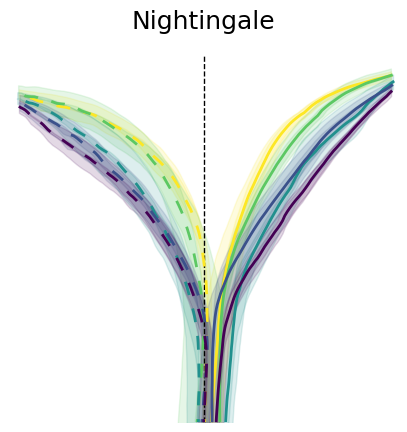

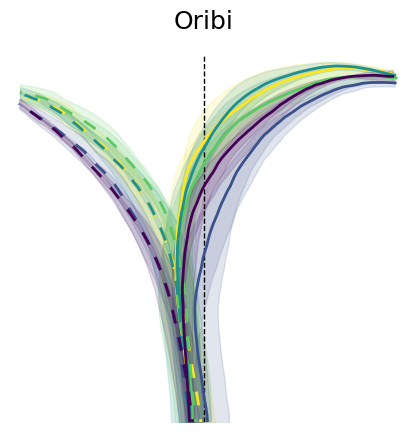

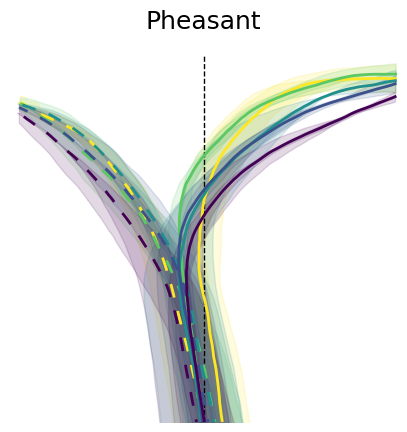

In [17]:
# Mean and error by mouse
mean_mouse = analysis.mean_xy_trajectory(xy_df,
                                         index_columns=[
                                             "mouse_name", "aperture", "trial_left_choice", "trial_length"
                                         ])

for m in mean_mouse.mouse_name.unique():
    plotting.plot_mean_xy_trajectory(mean_mouse[mean_mouse.mouse_name == m], cmap=plt.cm.viridis_r, color_by="aperture", style_by="choice")
    plt.title(m)
    plt.savefig(save_fig_path + f"figure5_trajectories_time_{m}.svg", transparent=True)
    plt.savefig(save_fig_path + f"figure5_trajectories_time_{m}.png", transparent=True, dpi=300)

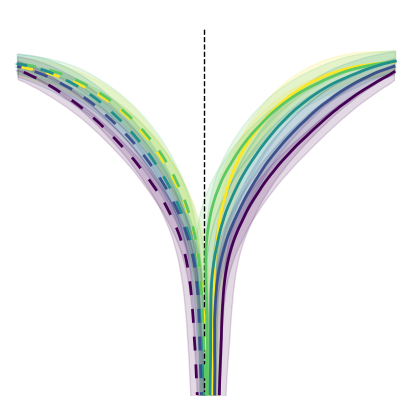

In [18]:
# Mean and error by aperture and choice
mean_group = analysis.mean_xy_trajectory(mean_mouse, 
                                         index_columns=[
                                             "aperture",  "trial_left_choice", "trial_length"
                                         ])

# Plot the mean trajectories from 0, 23 cm in y axis, -18, 18 cm in x axis, colored by choice and styled by aperture
plotting.plot_mean_xy_trajectory(mean_group, cmap=plt.cm.viridis_r, color_by="aperture", style_by="choice")

plt.savefig(save_fig_path + "figure5_trajectories_time.svg", transparent=True)
plt.savefig(save_fig_path + "figure5_trajectories_time.png", transparent=True, dpi=300)

## Stats on trajectories

In [19]:
y_binned_df = []
for m in sessions_list:
    try:
        y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "trial_left_choice", "x", "y", "flip_one_side", "trial_rewarded", "velocity", "trial_length", as_dict=True)[0]))
    except Exception as err:
        print(err)
y_binned_df = pd.concat(y_binned_df)

In [20]:
aperture_to_occlusion = {
    12.0: 99,
    8.48: 72,
    6.0: 35,
    4.2: 10,
    3.0: 0
}

y_binned_df["aperture"] = y_binned_df["aperture"].map(aperture_to_occlusion)
y_binned_df["mouse_name"] = y_binned_df.dataset.str.split("_").str [0]
y_binned_df["x_flipped"] = y_binned_df.x * y_binned_df.flip_one_side
data = utils.create_bins(y_binned_df)
y_binned_df_mean = analysis.mean_xy_trajectory(data, index_columns= ["dataset", "mouse_name", "aperture", "bin_centers"], values=["x_flipped", "y"])

                        Anova
                     F Value   Num DF   Den DF  Pr > F
------------------------------------------------------
aperture               8.8064  4.0000   96.0000 0.0000
bin_centers          145.7173 24.0000  576.0000 0.0000
aperture:bin_centers   2.5887 96.0000 2304.0000 0.0000



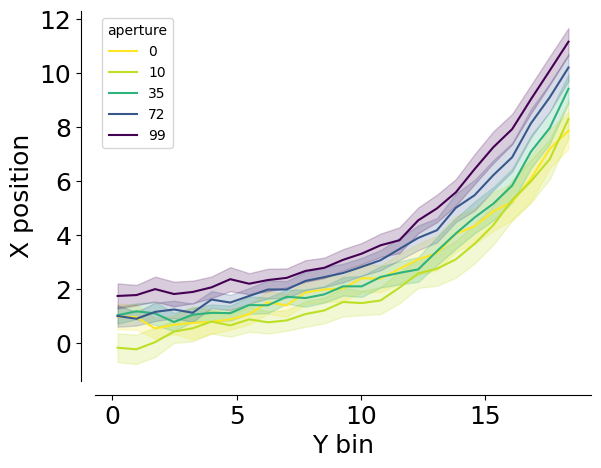

In [21]:
# NOTE(celia): Data unbalanced across bins, so only include bins so that balanced
stats_binned = y_binned_df_mean[(y_binned_df_mean.bin_centers >= 0) & (y_binned_df_mean.bin_centers <= 19)]

sns.lineplot(data=stats_binned, x="bin_centers", y="x_flipped", hue="aperture", palette= "viridis_r",errorbar="se")
plt.xlabel("Y bin")
plt.ylabel("X position")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure5_mean_xy_trajectory.svg")

print(
    AnovaRM(
        data=stats_binned,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

In [22]:
p_value_df = get_multi_p_values_binned(stats_binned, x_var="bin_centers", y_var="x_flipped")

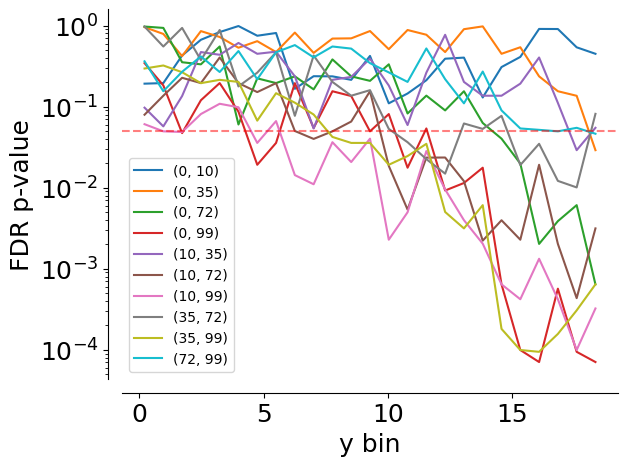

In [23]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.comp1, p_value_df.comp2))
plt.ylabel("FDR p-value")
plt.xlabel("y bin")
plt.yscale("log")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure5_pos_pvalue.svg", transparent=True)

In [24]:
p_value_df.pivot(index = "bin", columns=["comp1", "comp2"], values=["p_value_corr"])

p_value_corr                                                    \
comp1             0                                       10             
comp2             10        35        72        99        35        72   
bin                                                                      
0.2145      0.192174  0.956419  0.973089  0.344165  0.097154  0.079531   
0.9695      0.195309  0.788674  0.936356  0.182775  0.057112  0.136433   
1.7245      0.427642  0.420168  0.353099  0.047190  0.135254  0.226977   
2.4795      0.668287  0.854669  0.332668  0.119972  0.471501  0.195309   
3.2345      0.831765  0.723907  0.552567  0.195309  0.436272  0.403973   
3.9895      0.987504  0.532996  0.060248  0.086630  0.610762  0.195309   
4.7445      0.749459  0.642495  0.223488  0.019187  0.448858  0.151232   
5.5000      0.810183  0.471501  0.195309  0.035700  0.476597  0.194958   
6.2555      0.165944  0.819766  0.236456  0.194958  0.236456  0.050104   
7.0105      0.237446  0.460770  0.163390  0.054519  0.053834  0.040002   
7.7655      0.236456  0.691595  0.382658  0.154868  0.214212  0.049608   
8.5205      0.214212  0.696030  0.236456  0.135254  0.232779  0.065505   
9.2755      0.422486  0.856608  0.208157  0.049608  0.391246  0.154868   
10.0305     0.109896  0.511517  0.332668  0.081022  0.182355  0.018579   
10.7855     0.145267  0.882090  0.082383  0.017654  0.059304  0.005374   
11.5405     0.211958  0.771127  0.136726  0.053834  0.262764  0.023512   
12.2955     0.390403  0.471501  0.089899  0.009237  0.769869  0.023583   
13.0510     0.402682  0.902802  0.154868  0.011433  0.201915  0.012047   
13.8065     0.129775  0.977774  0.062885  0.017654  0.136433  0.002223   
14.5615     0.307954  0.448858  0.040284  0.000643  0.136433  0.003968   
15.3165     0.410721  0.540532  0.019861  0.000100  0.192174  0.002283   
16.0715     0.909310  0.236456  0.002027  0.000071  0.403973  0.019187   
16.8265     0.907086  0.154970  0.003869  0.000568  0.111218  0.002027   
17.5815     0.539659  0.136159  0.006096  0.000095  0.029046  0.000434   
18.3365     0.448858  0.029046  0.000643  0.000071  0.054841  0.003149   

                                                 
comp1                    35                  72  
comp2          99        72        99        99  
bin                                              
0.2145   0.060769  0.971913  0.295388  0.362481  
0.9695   0.049608  0.552200  0.321979  0.154970  
1.7245   0.048715  0.936356  0.265880  0.269191  
2.4795   0.081074  0.375018  0.194958  0.416613  
3.2345   0.108547  0.882090  0.214212  0.267612  
3.9895   0.098347  0.177661  0.201915  0.485269  
4.7445   0.035700  0.262764  0.067216  0.217900  
5.5000   0.066373  0.468058  0.146549  0.468699  
6.2555   0.014307  0.077088  0.111940  0.574385  
7.0105   0.011031  0.427642  0.079953  0.405357  
7.7655   0.036423  0.201915  0.042309  0.552200  
8.5205   0.020740  0.136433  0.035700  0.520192  
9.2755   0.040284  0.159660  0.035700  0.344165  
10.0305  0.002283  0.053131  0.019187  0.264710  
10.7855  0.004979  0.036423  0.024577  0.201915  
11.5405  0.028312  0.022509  0.034795  0.522318  
12.2955  0.009513  0.014921  0.005019  0.218224  
13.0510  0.003978  0.062014  0.003149  0.109896  
13.8065  0.002040  0.053159  0.006096  0.271056  
14.5615  0.000643  0.077088  0.000181  0.089899  
15.3165  0.000421  0.019044  0.000100  0.053834  
16.0715  0.001329  0.034795  0.000095  0.051742  
16.8265  0.000421  0.012141  0.000157  0.049608  
17.5815  0.000100  0.010084  0.000307  0.054841  
18.3365  0.000324  0.081518  0.000643  0.046315

## Velocity analysis

In [25]:
velocity_df = []
for m in sessions_list:
    #print(m)
    velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
velocity_df = pd.concat(velocity_df)

mean_mouse = velocity_df.groupby(["dataset", "aperture", "trial_length"],as_index=False).mean()

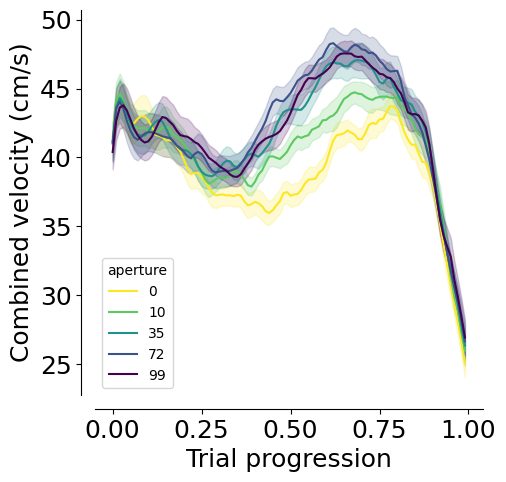

In [26]:
aperture_to_occlusion = {
    12.0: 99,
    8.48: 72,
    6.0: 35,
    4.2: 10,
    3.0: 0
}

# Map the values
mean_mouse['aperture'] = mean_mouse['aperture'].map(aperture_to_occlusion)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.lineplot(
    data=mean_mouse,
    x="trial_length",
    y="velocity",
    palette=plotting.colors_multi_aperture,
    hue="aperture",
    errorbar="se",
    ax=ax,
)

sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.savefig(save_fig_path + "figure5_velocity.svg", transparent=True)

In [27]:
print(
    AnovaRM(
        data=mean_mouse,
        depvar="velocity",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

                         Anova
                      F Value  Num DF    Den DF  Pr > F
-------------------------------------------------------
aperture              14.1673   4.0000   96.0000 0.0000
trial_length          41.8922  99.0000 2376.0000 0.0000
aperture:trial_length  5.3963 396.0000 9504.0000 0.0000



In [28]:
p_value_df = get_multi_p_values_binned(mean_mouse, x_var="trial_length", y_var="velocity")

In [29]:
p_value_df

,bin,comp1,comp2,p_value,p_value_corr
0,0.00,0,10,0.756933,0.848580
0,0.00,0,35,0.640678,0.772832
0,0.00,0,72,0.660219,0.784108
0,0.00,0,99,0.122099,0.264738
0,0.00,10,35,0.830888,0.899229
...,...,...,...,...,...
0,0.99,10,72,0.144746,0.295400
0,0.99,10,99,0.043505,0.120180
0,0.99,35,72,0.411949,0.598763
0,0.99,35,99,0.221908,0.404205


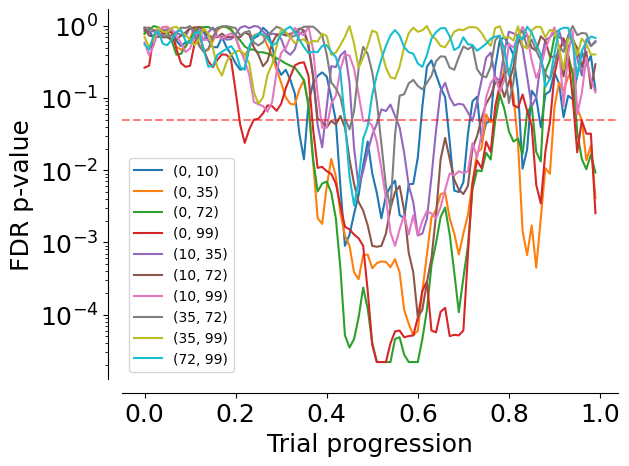

In [30]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.comp1, p_value_df.comp2))
plt.ylabel("FDR p-value")
plt.xlabel("Trial progression")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)
plt.yscale("log")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure5_velocity_pvalue.svg", transparent=True)